<a href="https://colab.research.google.com/github/Lazysedge/Klasifikasi-Kelayakan-Penerima-Beasiswa-Mahasiswa-Menggunakan-Algoritma-Machine-Learning-Sederhana/blob/main/Project_Beasiswa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [260]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from google.colab import files

In [261]:
uploaded = files.upload()

Saving beasiswa_5000.csv to beasiswa_5000.csv


In [262]:
df = pd.read_csv("beasiswa_5000.csv")

In [263]:
df.columns

Index(['IPK', 'Penghasilan', 'Tanggungan', 'Prestasi', 'Semester',
       'Status_Beasiswa'],
      dtype='object')

In [264]:
df.shape

(5000, 6)

In [265]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   IPK              5000 non-null   float64
 1   Penghasilan      5000 non-null   int64  
 2   Tanggungan       5000 non-null   int64  
 3   Prestasi         5000 non-null   object 
 4   Semester         5000 non-null   int64  
 5   Status_Beasiswa  5000 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 234.5+ KB


In [266]:
df.isnull().sum()

,0
IPK,0
Penghasilan,0
Tanggungan,0
Prestasi,0
Semester,0
Status_Beasiswa,0


In [267]:
df.describe()

,IPK,Penghasilan,Tanggungan,Semester
count,5000.000000,5.000000e+03,5000.000000,5000.000000
mean,3.246654,5.784342e+06,3.006400,5.059600
std,0.430234,2.440016e+06,1.405971,2.000512
min,2.500000,1.501658e+06,1.000000,2.000000
25%,2.880000,3.683676e+06,2.000000,3.000000
50%,3.255000,5.841042e+06,3.000000,5.000000
75%,3.610000,7.863788e+06,4.000000,7.000000
max,4.000000,9.996574e+06,5.000000,8.000000


In [268]:
df['Status_Beasiswa'].value_counts()

,count
Status_Beasiswa,
Layak,2951
Tidak Layak,2049


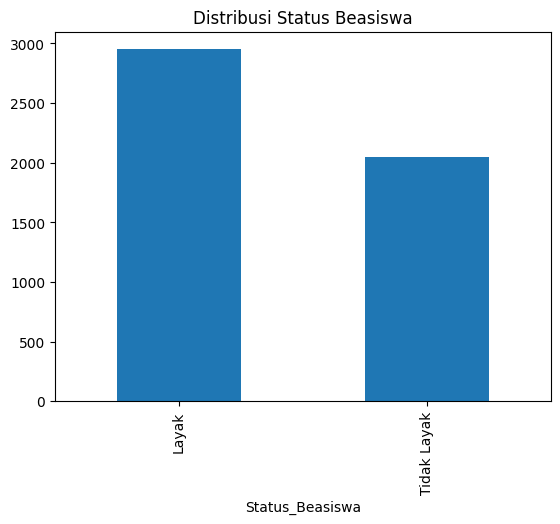

In [269]:
df['Status_Beasiswa'].value_counts().plot(
    kind='bar'
)

plt.title('Distribusi Status Beasiswa')
plt.show()

In [270]:
df['Prestasi'].value_counts()

,count
Prestasi,
Tidak Ada,2508
Ada,2492


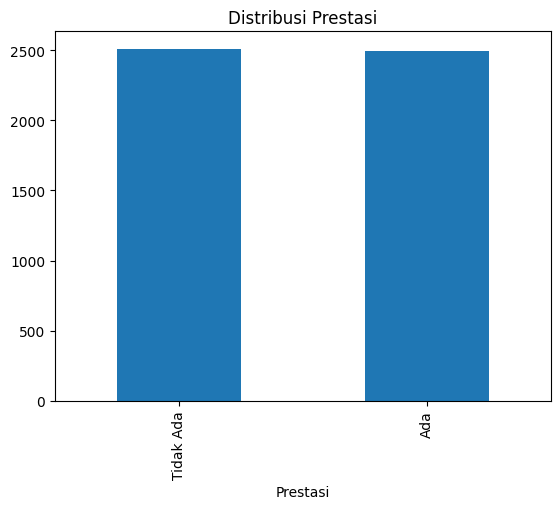

In [271]:
df['Prestasi'].value_counts().plot(
    kind='bar'
)

plt.title('Distribusi Prestasi')
plt.show()

In [272]:
df['IPK'].mean()

np.float64(3.246654)

In [273]:
df['Penghasilan'].mean()

np.float64(5784341.6842)

In [274]:
df['Prestasi'] = df['Prestasi'].map({
    'Ada': 1,
    'Tidak Ada': 0
})

df['Status_Beasiswa'] = df['Status_Beasiswa'].map({
    'Layak': 1,
    'Tidak Layak': 0
})

In [275]:
df.head()

,IPK,Penghasilan,Tanggungan,Prestasi,Semester,Status_Beasiswa
0,3.06,7923388,3,0,6,0
1,3.40,3734489,3,1,4,1
2,3.19,8704212,4,0,4,0
3,2.53,6481505,4,0,7,0
4,2.50,1603355,5,1,5,1


In [276]:
X = df[['IPK',
        'Penghasilan',
        'Tanggungan',
        'Prestasi',
        'Semester']]

y = df['Status_Beasiswa']

In [277]:
print(X.shape)
print(y.shape)

(5000, 5)
(5000,)


In [278]:
df.isnull().sum()

df['Status_Beasiswa'].value_counts()

,count
Status_Beasiswa,
1,2951
0,2049


In [279]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [280]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [281]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (4000, 5)
X_test  : (1000, 5)
y_train : (4000,)
y_test  : (1000,)


In [282]:
model = DecisionTreeClassifier(
    random_state=42
)

In [283]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [284]:
y_pred = model.predict(X_test)

In [285]:
hasil = pd.DataFrame({
    'Aktual': y_test,
    'Prediksi': y_pred
})

hasil.head(20)

,Aktual,Prediksi
1501,1,1
2586,1,1
2653,1,1
1055,0,0
705,0,0
106,0,0
589,0,0
2468,1,1
2413,0,0
1600,0,0


In [286]:
akurasi = accuracy_score(
    y_test,
    y_pred
)

print("Akurasi :", akurasi)

Akurasi : 0.969


In [287]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[395  15]
 [ 16 574]]


In [288]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       410
           1       0.97      0.97      0.97       590

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [289]:
print(df['Status_Beasiswa'].value_counts())

Status_Beasiswa
1    2951
0    2049
Name: count, dtype: int64


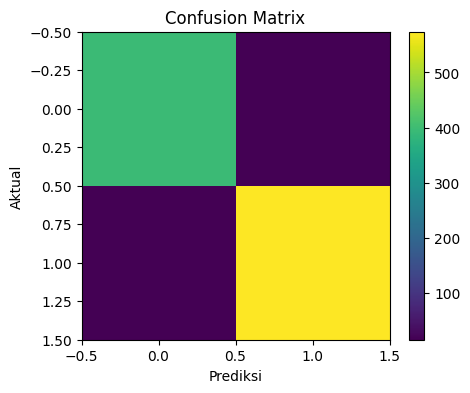

In [290]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

In [291]:
fitur = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': model.feature_importances_
})

fitur = fitur.sort_values(
    by='Importance',
    ascending=False
)

print(fitur)

         Fitur  Importance
1  Penghasilan    0.378508
3     Prestasi    0.310931
0          IPK    0.212936
2   Tanggungan    0.084359
4     Semester    0.013267


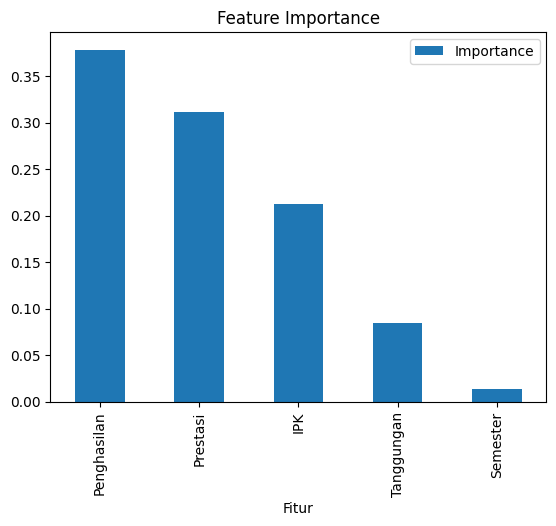

In [292]:
fitur.plot(
    x='Fitur',
    y='Importance',
    kind='bar'
)

plt.title("Feature Importance")
plt.show()

In [293]:
akurasi = accuracy_score(y_test, y_pred)

print(f"Akurasi Model: {akurasi:.2%}")

Akurasi Model: 96.90%


In [294]:
hasil_model = pd.DataFrame({
    'Metrik': ['Accuracy'],
    'Nilai': [akurasi]
})

hasil_model

,Metrik,Nilai
0,Accuracy,0.969


In [295]:
print(fitur)

         Fitur  Importance
1  Penghasilan    0.378508
3     Prestasi    0.310931
0          IPK    0.212936
2   Tanggungan    0.084359
4     Semester    0.013267


In [296]:
fitur['Persentase'] = fitur['Importance'] * 100

fitur

,Fitur,Importance,Persentase
1,Penghasilan,0.378508,37.850751
3,Prestasi,0.310931,31.093086
0,IPK,0.212936,21.293609
2,Tanggungan,0.084359,8.435875
4,Semester,0.013267,1.326679


In [297]:
fitur.to_csv(
    "feature_importance.csv",
    index=False
)

In [298]:
data_baru = pd.DataFrame({
    'IPK':[3.80],
    'Penghasilan':[2500000],
    'Tanggungan':[4],
    'Prestasi':[1],
    'Semester':[4]
})

prediksi = model.predict(data_baru)

print(prediksi)

[1]


In [299]:
data_baru = pd.DataFrame({
    'IPK':[3.20],
    'Penghasilan':[7500000],
    'Tanggungan':[2],
    'Prestasi':[0],
    'Semester':[3]
})

prediksi = model.predict(data_baru)

print(prediksi)

[0]


In [300]:
!pip install graphviz
!apt-get install graphviz -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [301]:
from sklearn.tree import export_graphviz
import graphviz

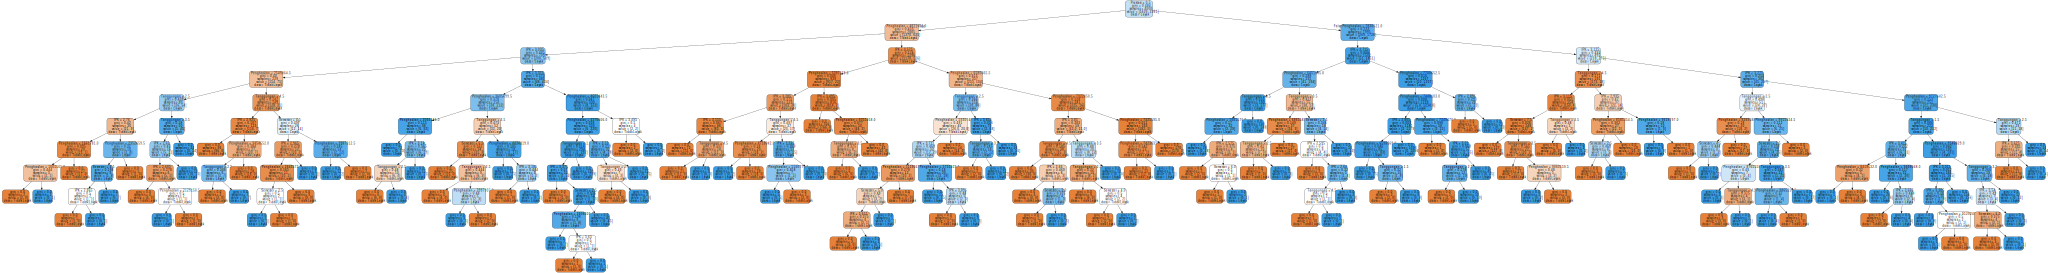

In [302]:
dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=['Tidak Layak', 'Layak'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)

graph

In [303]:
graph.render(
    "decision_tree",
    format="pdf",
    cleanup=True
)

'decision_tree.pdf'

In [304]:
from google.colab import files

files.download("decision_tree.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [305]:
def prediksi_beasiswa(
    ipk,
    penghasilan,
    tanggungan,
    prestasi,
    semester
):

    data = pd.DataFrame({
        'IPK':[ipk],
        'Penghasilan':[penghasilan],
        'Tanggungan':[tanggungan],
        'Prestasi':[prestasi],
        'Semester':[semester]
    })

    hasil = model.predict(data)

    if hasil[0] == 1:
        return "Layak"
    else:
        return "Tidak Layak"

In [306]:
prediksi_beasiswa(
    3.85,
    3000000,
    4,
    1,
    5
)

'Layak'

In [307]:
import joblib

joblib.dump(
    model,
    'model_beasiswa.pkl'
)

['model_beasiswa.pkl']

In [308]:
model = joblib.load(
    'model_beasiswa.pkl'
)

In [309]:
import os

print(os.listdir())

['.config', 'beasiswa_1000.csv', 'beasiswa_10000.csv', 'model_beasiswa.pkl', 'feature_importance.csv', 'beasiswa_5000.csv', 'beasiswa_100000.csv', 'decision_tree.pdf', 'beasiswa_100000 (1).csv', 'beasiswa_1000 (1).csv', 'sample_data']


In [310]:
!ls

'beasiswa_100000 (1).csv'   beasiswa_1000.csv	     model_beasiswa.pkl
 beasiswa_100000.csv	    beasiswa_5000.csv	     sample_data
 beasiswa_10000.csv	    decision_tree.pdf
'beasiswa_1000 (1).csv'     feature_importance.csv


In [311]:
from google.colab import files

files.download('model_beasiswa.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>